In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

%matplotlib inline

# BK2 physics: Simulation of a mass on a spring

## Introduction

The following paper will analyze eigen-frequencies in both a mechanical spring-mass-system and an electrical inductor-capacitor-circuit and draw parallels between these.

## Mechanical system

To answer our first research question, *How does the period of the oscillations, $T$, depend on $k$ and $m$?*, we need to make a simulation using a Newtonian model of the spring-mass-system using Hooke's law.

Using Newton's 2nd law,

$ \sum F = m \cdot a(t) $

and Hooke's law,

$ F_s = -k \cdot x(t) $

in our model, the total force acting upon the mass is equal to the force from the spring, that means:

$ m \cdot a(t) = -k \cdot x(t) $

$ m \cdot \frac{d^2}{dt^2} x(t) = -k \cdot x(t) $

We will therefore numerically integrate the above differential equation for our simulation using the Leap-Frog algorithm.

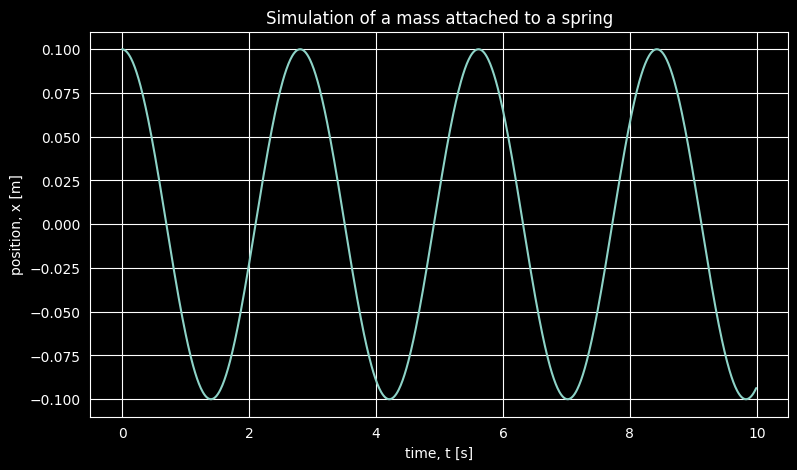

In [2]:
def LeapFrogSimple(p, dt, t_end, v0, x0):
    """ Run a numerical simulation of a mass and a spring using Leap-Frog.
    Parameters:
        p: ratio of spring constant (k) to mass (m)
        dt: timestep duration
        t_end: total time
        v0: initial velocity
        x0: initial position
    Returns:
        ttable: list of points in time
        xtable: list of positions
        vtable: list of velocities
    """
    
    n_steps = int(t_end/dt)  # Number of steps
    
    ttable = np.zeros(n_steps)
    xtable = np.zeros(n_steps)
    vtable = np.zeros(n_steps)
    
    t = 0.0
    x = x0
    v = v0
    
    for i in range(n_steps):
        ttable[i] = t
        xtable[i] = x
        vtable[i] = v
        
        t = t + dt
        a = (-p * x)
        v = v + a*dt  # a = dv/dt
        x = x + v*dt  # v = dx/dt
        

    
    return ttable,xtable,vtable

ttable, xtable, vtable = LeapFrogSimple(p=5, dt=0.01, t_end=10, v0=0, x0=0.1)

plt.figure(figsize=(9, 5))
plt.plot(ttable, xtable,'-')
plt.title("Simulation of a mass attached to a spring")
plt.xlabel("time, t [s]")
plt.ylabel("position, x [m]")
plt.show()

Repeating this simulation only changing the parameter, $ p = \frac k m $, we can plot the relationship between this parameter and the period, $T$.

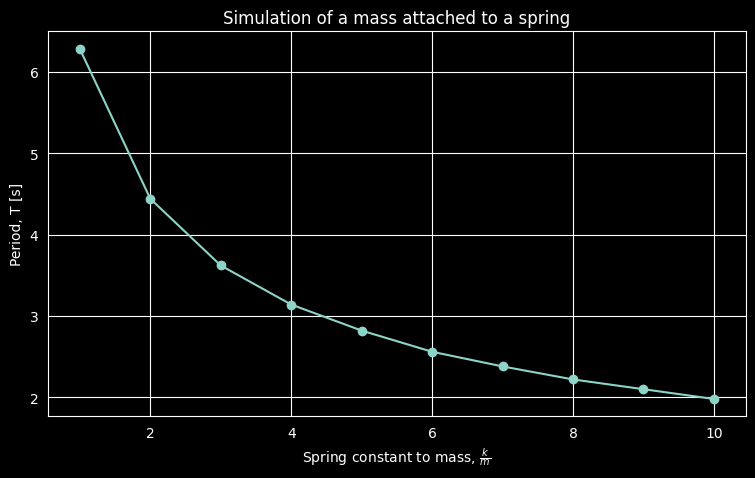

In [3]:
def FindPeriod(xtable, ttable):
    n = len(xtable)
    signshifts = np.argwhere(xtable[1:n]*xtable[0:n-1]<0)
    if len(signshifts)<2:
        print('Simulation not long enough to determine period!')
        return 0
    return 2*ttable[signshifts[1] - signshifts[0]][0]

size = 10
ptable = np.zeros(size)
Ttable = np.zeros(size)

for i in range(size):
    p = i + 1
    ttable, xtable, vtable = LeapFrogSimple(p=p, dt=0.01, t_end=10, v0=0, x0=0.1)
    T = FindPeriod(xtable, ttable)
    ptable[i] = p
    Ttable[i] = T

plt.figure(figsize=(9, 5))
plt.plot(ptable, Ttable, '-o')
plt.title("Simulation of a mass attached to a spring")
plt.xlabel("Spring constant to mass, " + r"$\frac{k}{m}$")
plt.ylabel("Period, T [s]")
plt.show()

Plotting the same data with log-log scales yields:

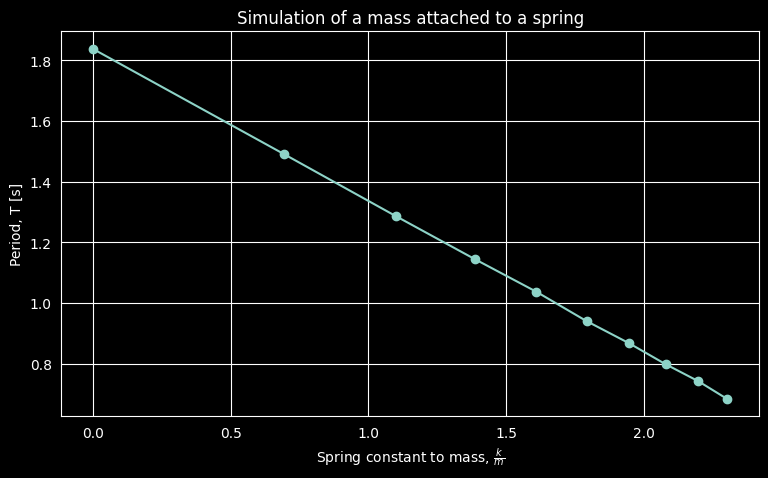

In [4]:
plt.figure(figsize=(9, 5))
plt.plot(np.log(ptable), np.log(Ttable), '-o')
plt.title("Simulation of a mass attached to a spring")
plt.xlabel("Spring constant to mass, " + r"$\frac{k}{m}$")
plt.ylabel("Period, T [s]")
plt.show()

This seems like a linear relationship. Doing linear regression on the data shows 

In [5]:
a, b = np.polyfit(np.log(ptable),np.log(Ttable),1)
print(f'y={a}x+{b}')

y=-0.49965478086019743x+1.8372099153349024


The relationship is the following:

$ T = {\frac k m}^{-0.50} \cdot \exp(1.84) $

which agrees with our theoretical model that says:

$ T = 2\pi \sqrt{\frac{m}{k}} \approx \exp(1.84) \sqrt{\frac m k} $

To answer our 2nd research question, *Under which conditions does our simulated spring-mass system exhibit a resonance?*, we add a small extra oscillating force or pertubation, $ F_e = 0.01 \cos(\frac{2\pi t}{T_e}) $, where $T_e$ is the period of the pertubation. We simply reuse the Leap-Frog algorithm with the extra pertubation:

In [6]:
def LeapFrog_extra(m, k, dt, t_end, v0, x0, Te):
    """ Run a numerical simulation of a mass and a spring using Leap-Frog.
    Parameters:
        m: mass
        k: spring constant
        dt: derivation of time
        t_end: total time
        v0: initial velocity
        x0: initial position
        Te: period of pertubation
    Returns:
        ttable: list of points in time
        xtable: list of positions
        vtable: list of velocities
    """
    
    n_steps = int(t_end/dt)  # Number of steps
    
    ttable = np.zeros(n_steps)
    xtable = np.zeros(n_steps)
    vtable = np.zeros(n_steps)
    
    t = 0.0
    x = x0
    v = v0
    
    for i in range(n_steps):
        ttable[i] = t
        xtable[i] = x
        vtable[i] = v
        
        t = t + dt
        Fe =  0.01*np.cos(2*np.pi*t/Te)
        a = ((-k * x) + Fe) / m
        v = v + a*dt  # a = dv/dt
        x = x + v*dt  # v = dx/dt
            
    return ttable,xtable,vtable

Repeating 50 times changing only the parameter, $T_e$:

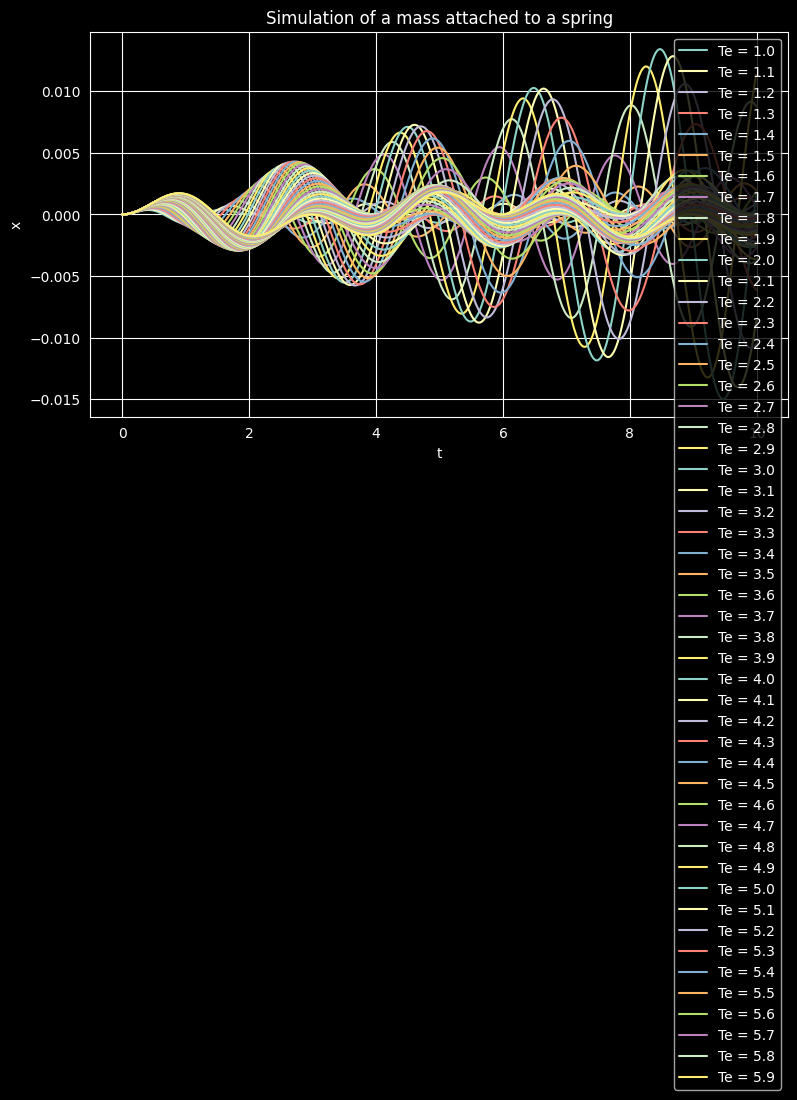

In [7]:
n = 50
plt.figure(figsize=(9, 5))
xmax = []
Telist = []
for i in range(n):
    Te = 0.1*i + 1
    ttable, xtable, vtable = LeapFrog_extra(m=1, k=10, dt=0.01, t_end=10, v0=0, x0=0, Te=Te)
    plt.plot(ttable,xtable,'-', label=f'Te = {Te:.1f}')
    xmax.append(xtable.max())
    Telist.append(Te)

plt.title("Simulation of a mass attached to a spring")
plt.xlabel("t")
plt.ylabel("x")
plt.legend()
plt.show()

Plotting the relationship between $T_e$ and the maximum displacement, we get the following.

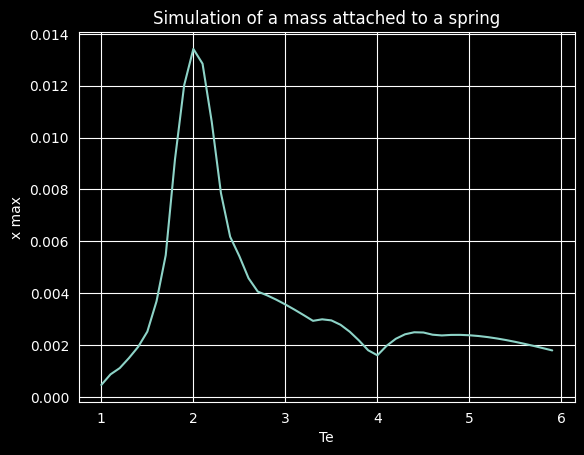

In [8]:
plt.figure()
plt.title("Simulation of a mass attached to a spring")
plt.xlabel("Te")
plt.ylabel("x max")
plt.plot(Telist ,xmax)
plt.show()

We can conclude the eigen-frequency is when $T_e \approx 2.1$.

### Ex. 11

Exercise 11. (optional) Add friction to your spring. There are different
ways to model friction. Assume that the friction force is proportional to the
velocity. What effect does the friction have? (you should probably start by
removing the pertubation from exercise 10).

## Electrical system

### Ex. 6

Does the measured amplitude match the amplitude you have chosen on the gene-
rator? Explain how you see that.

For the next section on the electrical circuit to answer our research question " " we will be doing an experiment using a circuit, a resistor, 4 inductors, a capacitor, a voltage generator and a oscilloscope.

Our chosen voltage is $1.25 V$ and the oscilloscope measures Voltage from peak to peak, that is twice the given voltage, in the picture the peak to peak value is 2.5 V therefore our chosen value and the voltage displayed on the oscilloscope are the same as seen below.

![](0.jpg)

For our first experiment we will use Ohms Law, $ \sum U = R\cdot I$ to find the resistance of an unknown resistor in our circuit. To do this we will connect the circuit board to the oscilloscope such that the voltage over the known resistor, $R_k$, is measured on Channel 2. We will then use these values to extract the resistance of the unkown resistor $R_u$.


$ U_1 = 9.1 V$

$ U_2 = 0.177 V $

$ I = \frac{U_2}{R_k} = \frac{U_2}{10 \ohm} = 1.77\cdot 10^{-4} A$

$R_u = \frac{U_1}{I} = \frac{9.1 V}{177 \cdot 10^{-4} A} = 514 \ohm$


### Ex. 16

Vary the frequency and measure the voltage drop, U1, and the current, I = U2/10Ω
at least 10 frequencies in the range 2 kHz to 20 kHz. Report the data in a script
as the one shown below and include it in your report.

Our following experiment will answer the question '', by setting up a circuit with a capacitor and an inductor. Using the generator we will vary the frequency of the voltage given in order to find eigen-frequencies of our inductors.

In [9]:
f = np.array([
    2, 4, 6, 8, 10, 12, 14, 16, 18, 20
])

# RED
ppU1 = np.array([
    20.0, 19.9, 19.1, 13.1, 14.5, 18.6, 19.3, 19.6, 19.7, 19.8
])
ppU2 = np.array([
    0.178, 0.415, 0.880, 2.300, 2.000, 1.100, 0.766, 0.590, 0.484, 0.411
])

U1 = ppU1/2
U2 = ppU2/2
I = U2/10

Plotting our results yields the following figure:

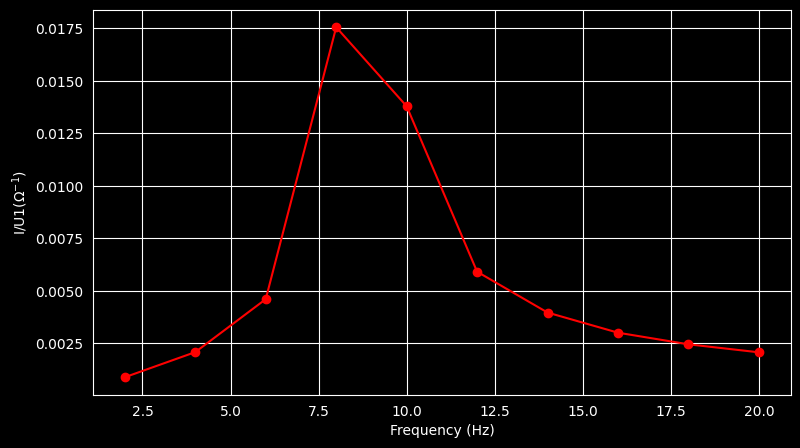

In [20]:
plt.figure(figsize=(9, 5))
plt.plot(f, I/U1,'-o', color='Red')
# plt.title("")
plt.xlabel("Frequency (Hz)")
plt.ylabel('I/U1'+ r'($\Omega^{-1}$)')
# plt.legend()
plt.show()

Our maximum is when $f \approx 8800 Hz$ on the oscilloscope we can see that the phase angle (?) tends to zero as we get near the eigen-frequency.

### Ex. 21

Plot the period Tres as a function of L both in a normal linear plot and a log-log
plot. What do you see, and what does it tell you about the relation between
Tres and L? Both plots should be in your report if you answer this part.

By repeating this process 3 more times and plotting the resonance period and the inductance in a log-log axis plot we get the following figure:

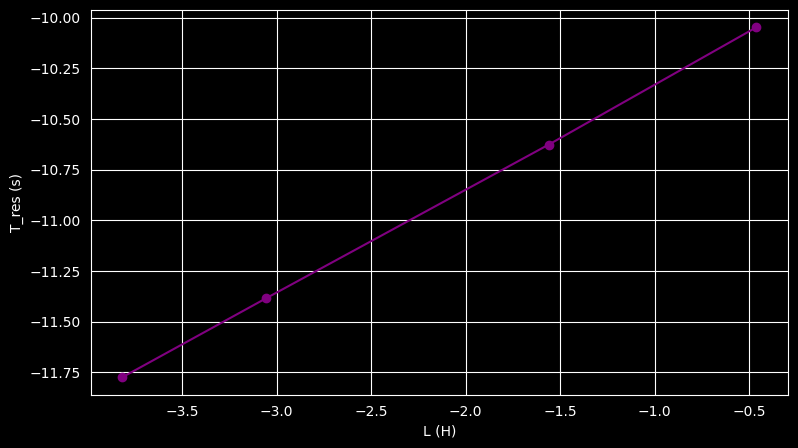

In [23]:
# pink, red, glitter, black
L = np.array([2.2, 4.7, 21, 63]) #mH
f_res = np.array([12.98, 8.80, 4.12, 2.31]) # kHz
T_res = 1/(f_res*10e3)

plt.figure(figsize=(9, 5))
plt.plot(np.log(L*10e-3), np.log(T_res),'-o', color='Purple')
# plt.title("")
plt.xlabel("L (H)")
plt.ylabel("T_res (s)")
# plt.legend()
plt.show()

Doing linear regression on the data above yields the following equation.

In [24]:
a, b = np.polyfit(np.log(L*10e-3), np.log(T_res), 1)
print(a, b)
C = (np.exp(b)/(2*np.pi)) ** 2

0.5134892404614555 -9.816026982685136


$ y = x^{0.513} \cdot \exp(-6.33) $

$ T = 2\pi \sqrt{LC} $

In [27]:
# TODO: Mechanics 4,5,6,7,9, (11), draw concrete parallels to section 1 from our results, include diagram of circuit.